In [1]:
# Step 1: Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import joblib
import os

pd.set_option("display.max_columns", None)

In [2]:
# Step 2: Load prepared dataset

df = pd.read_csv("../data/heart_disease_prepared.csv")

df.head()

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [3]:
# Step 3: Load saved model and scaler

model = joblib.load("../models/logistic_regression_model.pkl")
scaler = joblib.load("../models/scaler.pkl")

print("Model and scaler loaded successfully")

Model and scaler loaded successfully


In [4]:
# Step 4: Load model comparison results

model_results = pd.read_csv("../models/model_comparison_results.csv")

model_results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.7534,0.2482,0.7970,0.3785,0.8470
1,Random Forest,0.8996,0.3761,0.0994,0.1572,0.8127
2,XGBoost,0.9078,0.5605,0.0998,0.1694,0.8508


In [5]:
# Step 5: Load SHAP feature importance

shap_importance = pd.read_csv("../models/shap_feature_importance.csv")

shap_importance.head(15)

,Feature,Mean Absolute SHAP Value
0,Age,0.685970
1,GenHlth,0.442880
2,Sex,0.408210
3,HighChol,0.316588
4,HighBP,0.268089
5,Smoker,0.188891
6,Stroke,0.096427
7,Income,0.093979
8,DiffWalk,0.087160
9,Diabetes,0.069863


In [6]:
# Step 6: Prepare target distribution data for dashboard

target_counts = df["HeartDiseaseorAttack"].value_counts().reset_index()
target_counts.columns = ["HeartDiseaseorAttack", "Count"]

target_counts["Heart Disease Status"] = target_counts["HeartDiseaseorAttack"].map({
    0.0: "No Heart Disease / Attack",
    1.0: "Heart Disease / Attack"
})

target_counts

,HeartDiseaseorAttack,Count,Heart Disease Status
0,0.0,229787,No Heart Disease / Attack
1,1.0,23893,Heart Disease / Attack


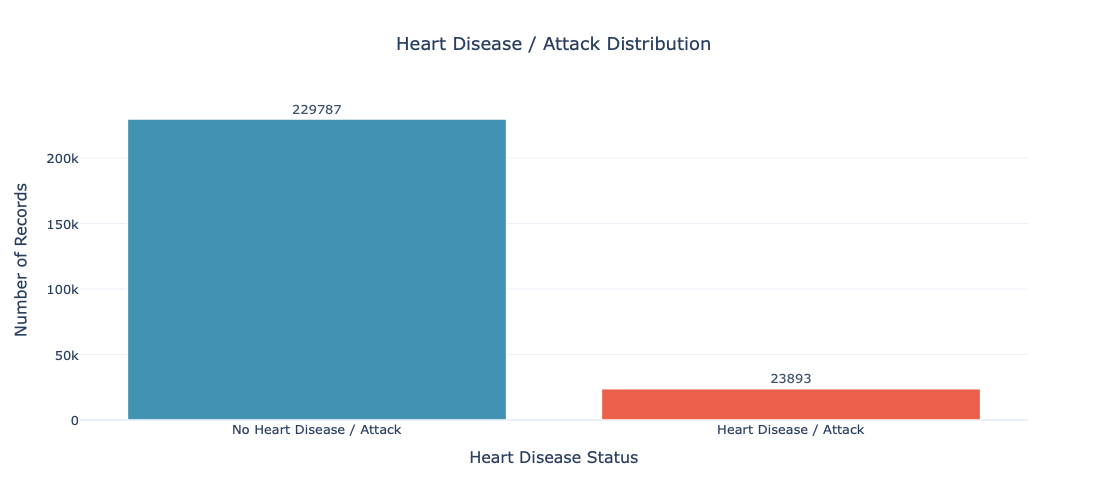

In [8]:
# Step 7: Create interactive target distribution graph

fig_target = px.bar(
    target_counts,
    x="Heart Disease Status",
    y="Count",
    text="Count",
    title="Heart Disease / Attack Distribution",
    color="Heart Disease Status",
    color_discrete_map={
        "No Heart Disease / Attack": "#2E86AB",
        "Heart Disease / Attack": "#E94F37"
    }
)

fig_target.update_traces(
    textposition="outside",
    marker_line_color="white",
    marker_line_width=1.5,
    opacity=0.9,
    hovertemplate="<b>%{x}</b><br>Number of Records: %{y}<extra></extra>"
)

fig_target.update_layout(
    xaxis_title="Heart Disease Status",
    yaxis_title="Number of Records",
    showlegend=False,
    title_x=0.5,
    template="plotly_white",
    width=850,
    height=500,
    font=dict(size=13),
    plot_bgcolor="white",
    paper_bgcolor="white"
)

fig_target

In [9]:
# Step 8: Save target distribution graph as HTML

os.makedirs("../dashboard_graphs", exist_ok=True)

fig_target.write_html("../dashboard_graphs/target_distribution.html")

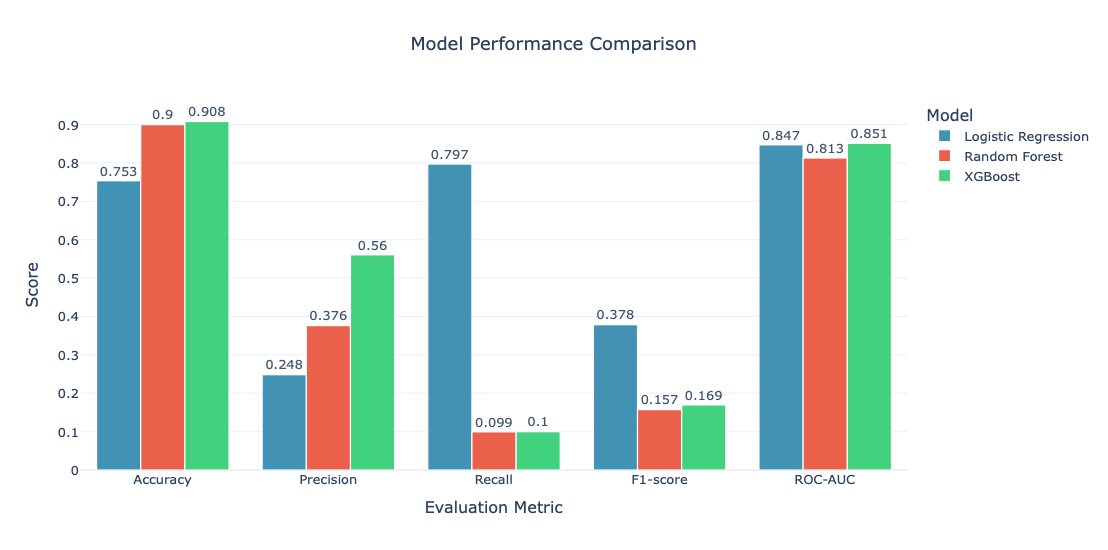

In [10]:
# Step 9: Create interactive model performance comparison graph

model_results_long = model_results.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    var_name="Metric",
    value_name="Score"
)

fig_model_comparison = px.bar(
    model_results_long,
    x="Metric",
    y="Score",
    color="Model",
    barmode="group",
    text=model_results_long["Score"].round(3),
    title="Model Performance Comparison",
    color_discrete_map={
        "Logistic Regression": "#2E86AB",
        "Random Forest": "#E94F37",
        "XGBoost": "#2ECC71"
    }
)

fig_model_comparison.update_traces(
    textposition="outside",
    marker_line_color="white",
    marker_line_width=1.2,
    opacity=0.9,
    hovertemplate="<b>%{fullData.name}</b><br>Metric: %{x}<br>Score: %{y:.3f}<extra></extra>"
)

fig_model_comparison.update_layout(
    xaxis_title="Evaluation Metric",
    yaxis_title="Score",
    title_x=0.5,
    template="plotly_white",
    width=950,
    height=550,
    font=dict(size=13),
    plot_bgcolor="white",
    paper_bgcolor="white"
)

fig_model_comparison

In [11]:
# Step 10: Save model performance comparison graph as HTML

fig_model_comparison.write_html("../dashboard_graphs/model_performance_comparison.html")

### Interpretation

This graph compares Logistic Regression, Random Forest, and XGBoost using accuracy, precision, recall, F1-score, and ROC-AUC. Although Random Forest and XGBoost show higher accuracy, Logistic Regression has much stronger recall, which is important for identifying actual heart disease/heart attack cases.

In [12]:
# Step 11: Prepare SHAP top features for dashboard

top_shap_features = shap_importance.head(15)

top_shap_features

,Feature,Mean Absolute SHAP Value
0,Age,0.685970
1,GenHlth,0.442880
2,Sex,0.408210
3,HighChol,0.316588
4,HighBP,0.268089
5,Smoker,0.188891
6,Stroke,0.096427
7,Income,0.093979
8,DiffWalk,0.087160
9,Diabetes,0.069863


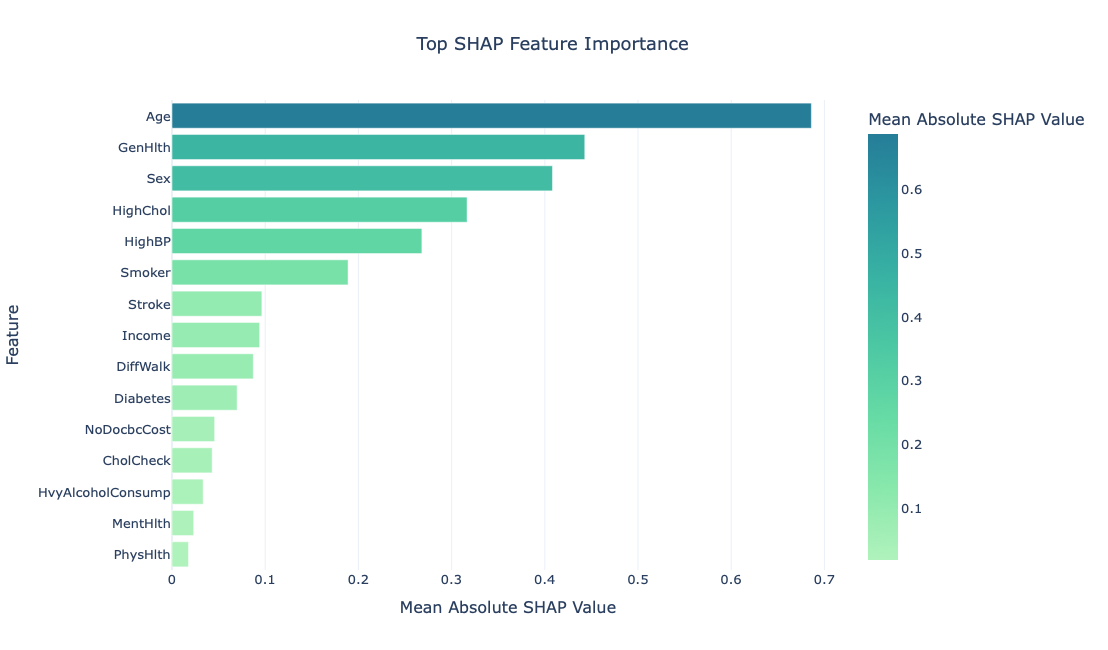

In [13]:
# Step 12: Create interactive SHAP feature importance graph

fig_shap = px.bar(
    top_shap_features.sort_values(by="Mean Absolute SHAP Value"),
    x="Mean Absolute SHAP Value",
    y="Feature",
    orientation="h",
    title="Top SHAP Feature Importance",
    color="Mean Absolute SHAP Value",
    color_continuous_scale="Tealgrn"
)

fig_shap.update_traces(
    hovertemplate="<b>%{y}</b><br>Mean Absolute SHAP Value: %{x:.4f}<extra></extra>"
)

fig_shap.update_layout(
    xaxis_title="Mean Absolute SHAP Value",
    yaxis_title="Feature",
    title_x=0.5,
    template="plotly_white",
    width=900,
    height=650,
    font=dict(size=13),
    plot_bgcolor="white",
    paper_bgcolor="white"
)

fig_shap

In [14]:
# Step 13: Save SHAP feature importance graph as HTML

fig_shap.write_html("../dashboard_graphs/shap_feature_importance.html")

### Interpretation

This graph shows the top SHAP features influencing the Logistic Regression model. These features help explain which variables had the strongest impact on heart disease/heart attack prediction and will be useful in the final dashboard, app, and presentation.

In [15]:
# Step 14: Define app input features

app_features = [
    "HighBP",
    "HighChol",
    "CholCheck",
    "BMI",
    "Smoker",
    "Stroke",
    "Diabetes",
    "PhysActivity",
    "Fruits",
    "Veggies",
    "HvyAlcoholConsump",
    "AnyHealthcare",
    "NoDocbcCost",
    "GenHlth",
    "MentHlth",
    "PhysHlth",
    "DiffWalk",
    "Sex",
    "Age",
    "Education",
    "Income"
]

app_features

['HighBP',
 'HighChol',
 'CholCheck',
 'BMI',
 'Smoker',
 'Stroke',
 'Diabetes',
 'PhysActivity',
 'Fruits',
 'Veggies',
 'HvyAlcoholConsump',
 'AnyHealthcare',
 'NoDocbcCost',
 'GenHlth',
 'MentHlth',
 'PhysHlth',
 'DiffWalk',
 'Sex',
 'Age',
 'Education',
 'Income']

In [16]:
# Step 15: Confirm app feature order matches training feature order

training_features = df.drop("HeartDiseaseorAttack", axis=1).columns.tolist()

app_features == training_features

True

In [17]:
# Step 16: Create feature value guide for app inputs

feature_value_guide = {
    "HighBP": "0 = No high blood pressure, 1 = High blood pressure",
    "HighChol": "0 = No high cholesterol, 1 = High cholesterol",
    "CholCheck": "0 = No cholesterol check in 5 years, 1 = Cholesterol check in 5 years",
    "BMI": "Body Mass Index value",
    "Smoker": "0 = Non-smoker, 1 = Smoker",
    "Stroke": "0 = No stroke history, 1 = Stroke history",
    "Diabetes": "0 = No diabetes, 1 = Pre-diabetes, 2 = Diabetes",
    "PhysActivity": "0 = No physical activity, 1 = Physical activity",
    "Fruits": "0 = Does not consume fruit daily, 1 = Consumes fruit daily",
    "Veggies": "0 = Does not consume vegetables daily, 1 = Consumes vegetables daily",
    "HvyAlcoholConsump": "0 = No heavy alcohol consumption, 1 = Heavy alcohol consumption",
    "AnyHealthcare": "0 = No healthcare coverage, 1 = Has healthcare coverage",
    "NoDocbcCost": "0 = Could see doctor when needed, 1 = Could not see doctor due to cost",
    "GenHlth": "1 = Excellent, 2 = Very good, 3 = Good, 4 = Fair, 5 = Poor",
    "MentHlth": "Poor mental health days in last 30 days",
    "PhysHlth": "Poor physical health days in last 30 days",
    "DiffWalk": "0 = No difficulty walking, 1 = Difficulty walking",
    "Sex": "0 = Female, 1 = Male",
    "Age": "1 = 18-24, 2 = 25-29, 3 = 30-34, 4 = 35-39, 5 = 40-44, 6 = 45-49, 7 = 50-54, 8 = 55-59, 9 = 60-64, 10 = 65-69, 11 = 70-74, 12 = 75-79, 13 = 80+",
    "Education": "1 to 6 education category",
    "Income": "1 to 8 income category"
}

feature_value_guide

{'HighBP': '0 = No high blood pressure, 1 = High blood pressure',
 'HighChol': '0 = No high cholesterol, 1 = High cholesterol',
 'CholCheck': '0 = No cholesterol check in 5 years, 1 = Cholesterol check in 5 years',
 'BMI': 'Body Mass Index value',
 'Smoker': '0 = Non-smoker, 1 = Smoker',
 'Stroke': '0 = No stroke history, 1 = Stroke history',
 'Diabetes': '0 = No diabetes, 1 = Pre-diabetes, 2 = Diabetes',
 'PhysActivity': '0 = No physical activity, 1 = Physical activity',
 'Fruits': '0 = Does not consume fruit daily, 1 = Consumes fruit daily',
 'Veggies': '0 = Does not consume vegetables daily, 1 = Consumes vegetables daily',
 'HvyAlcoholConsump': '0 = No heavy alcohol consumption, 1 = Heavy alcohol consumption',
 'AnyHealthcare': '0 = No healthcare coverage, 1 = Has healthcare coverage',
 'NoDocbcCost': '0 = Could see doctor when needed, 1 = Could not see doctor due to cost',
 'GenHlth': '1 = Excellent, 2 = Very good, 3 = Good, 4 = Fair, 5 = Poor',
 'MentHlth': 'Poor mental health day

In [18]:
# Step 17: Convert feature value guide to DataFrame

feature_guide_df = pd.DataFrame(
    list(feature_value_guide.items()),
    columns=["Feature", "Value Guide"]
)

feature_guide_df

,Feature,Value Guide
0,HighBP,"0 = No high blood pressure, 1 = High blood pre..."
1,HighChol,"0 = No high cholesterol, 1 = High cholesterol"
2,CholCheck,"0 = No cholesterol check in 5 years, 1 = Chole..."
3,BMI,Body Mass Index value
4,Smoker,"0 = Non-smoker, 1 = Smoker"
5,Stroke,"0 = No stroke history, 1 = Stroke history"
6,Diabetes,"0 = No diabetes, 1 = Pre-diabetes, 2 = Diabetes"
7,PhysActivity,"0 = No physical activity, 1 = Physical activity"
8,Fruits,"0 = Does not consume fruit daily, 1 = Consumes..."
9,Veggies,"0 = Does not consume vegetables daily, 1 = Con..."


In [19]:
# Step 18: Save feature value guide for app/dashboard

feature_guide_df.to_csv("../models/app_feature_value_guide.csv", index=False)

### Interpretation

The app input feature guide explains how each input variable should be entered in the final Gradio app. This is important because many features are coded as numeric categories, such as age group, general health, diabetes status, education, and income.

In [20]:
# Step 19: Create prediction function for the app

def predict_heart_disease(
    HighBP,
    HighChol,
    CholCheck,
    BMI,
    Smoker,
    Stroke,
    Diabetes,
    PhysActivity,
    Fruits,
    Veggies,
    HvyAlcoholConsump,
    AnyHealthcare,
    NoDocbcCost,
    GenHlth,
    MentHlth,
    PhysHlth,
    DiffWalk,
    Sex,
    Age,
    Education,
    Income
):
    # Build the model-ready row (must match Notebook 1 feature engineering)
    diabetes_any = 1 if Diabetes > 0 else 0
    risk_factor_count = HighBP + HighChol + Smoker + Stroke + DiffWalk + diabetes_any
    total_poor_health_days = MentHlth + PhysHlth

    row = {
        "HighBP": HighBP, "HighChol": HighChol, "CholCheck": CholCheck, "BMI": BMI,
        "Smoker": Smoker, "Stroke": Stroke, "PhysActivity": PhysActivity, "Fruits": Fruits,
        "Veggies": Veggies, "HvyAlcoholConsump": HvyAlcoholConsump, "AnyHealthcare": AnyHealthcare,
        "NoDocbcCost": NoDocbcCost, "GenHlth": GenHlth, "MentHlth": MentHlth, "PhysHlth": PhysHlth,
        "DiffWalk": DiffWalk, "Sex": Sex, "Age": Age, "Education": Education, "Income": Income,
        "risk_factor_count": risk_factor_count,
        "total_poor_health_days": total_poor_health_days,
        "Diabetes_1.0": 1 if Diabetes == 1 else 0,
        "Diabetes_2.0": 1 if Diabetes == 2 else 0,
    }

    model_features = [
        "HighBP", "HighChol", "CholCheck", "BMI", "Smoker", "Stroke",
        "PhysActivity", "Fruits", "Veggies", "HvyAlcoholConsump", "AnyHealthcare",
        "NoDocbcCost", "GenHlth", "MentHlth", "PhysHlth", "DiffWalk", "Sex",
        "Age", "Education", "Income", "risk_factor_count", "total_poor_health_days",
        "Diabetes_1.0", "Diabetes_2.0"
    ]

    input_data = pd.DataFrame([row])[model_features]
    input_scaled = scaler.transform(input_data)

    prediction = model.predict(input_scaled)[0]
    probability = model.predict_proba(input_scaled)[0][1]

    if prediction == 1:
        risk_label = "Higher Heart Disease / Attack Risk"
    else:
        risk_label = "Lower Heart Disease / Attack Risk"

    return risk_label, round(probability * 100, 2)

In [21]:
# Step 20: Test prediction function with sample input

test_prediction = predict_heart_disease(
    HighBP=1,
    HighChol=1,
    CholCheck=1,
    BMI=30,
    Smoker=1,
    Stroke=0,
    Diabetes=2,
    PhysActivity=0,
    Fruits=0,
    Veggies=1,
    HvyAlcoholConsump=0,
    AnyHealthcare=1,
    NoDocbcCost=0,
    GenHlth=4,
    MentHlth=5,
    PhysHlth=10,
    DiffWalk=1,
    Sex=1,
    Age=10,
    Education=4,
    Income=5
)

test_prediction

('Higher Heart Disease / Attack Risk', np.float64(90.66))

### Interpretation

The prediction function takes user input values, scales them using the saved scaler, and uses the saved Logistic Regression model to return a heart disease/heart attack risk label and predicted probability. This function will be used later inside the final Gradio app.

In [22]:
# Step 21: Create user-friendly risk message function

def create_risk_message(risk_label, probability):
    if probability >= 70:
        message = "The model predicts a higher risk probability. This result suggests the user may have several risk-related health indicators."
    elif probability >= 40:
        message = "The model predicts a moderate risk probability. Some health indicators may be contributing to the prediction."
    else:
        message = "The model predicts a lower risk probability based on the information provided."
    
    disclaimer = "This result is for educational and portfolio purposes only. It is not a medical diagnosis and should not be used for clinical decision-making."
    
    return message, disclaimer

In [23]:
# Step 22: Test risk message function

risk_label, probability = test_prediction

message, disclaimer = create_risk_message(risk_label, probability)

print("Risk Label:", risk_label)
print("Probability:", probability, "%")
print("Message:", message)
print("Disclaimer:", disclaimer)

Risk Label: Higher Heart Disease / Attack Risk
Probability: 90.66 %
Message: The model predicts a higher risk probability. This result suggests the user may have several risk-related health indicators.
Disclaimer: This result is for educational and portfolio purposes only. It is not a medical diagnosis and should not be used for clinical decision-making.


In [24]:
# Step 23: Create final app prediction output function

def app_prediction_output(
    HighBP,
    HighChol,
    CholCheck,
    BMI,
    Smoker,
    Stroke,
    Diabetes,
    PhysActivity,
    Fruits,
    Veggies,
    HvyAlcoholConsump,
    AnyHealthcare,
    NoDocbcCost,
    GenHlth,
    MentHlth,
    PhysHlth,
    DiffWalk,
    Sex,
    Age,
    Education,
    Income
):
    risk_label, probability = predict_heart_disease(
        HighBP,
        HighChol,
        CholCheck,
        BMI,
        Smoker,
        Stroke,
        Diabetes,
        PhysActivity,
        Fruits,
        Veggies,
        HvyAlcoholConsump,
        AnyHealthcare,
        NoDocbcCost,
        GenHlth,
        MentHlth,
        PhysHlth,
        DiffWalk,
        Sex,
        Age,
        Education,
        Income
    )
    
    message, disclaimer = create_risk_message(risk_label, probability)
    
    return {
        "Risk Prediction": risk_label,
        "Predicted Probability (%)": probability,
        "Explanation": message,
        "Disclaimer": disclaimer
    }

In [25]:
# Step 24: Test final app output function

app_prediction_output(
    HighBP=1,
    HighChol=1,
    CholCheck=1,
    BMI=30,
    Smoker=1,
    Stroke=0,
    Diabetes=2,
    PhysActivity=0,
    Fruits=0,
    Veggies=1,
    HvyAlcoholConsump=0,
    AnyHealthcare=1,
    NoDocbcCost=0,
    GenHlth=4,
    MentHlth=5,
    PhysHlth=10,
    DiffWalk=1,
    Sex=1,
    Age=10,
    Education=4,
    Income=5
)

{'Risk Prediction': 'Higher Heart Disease / Attack Risk',
 'Predicted Probability (%)': np.float64(90.66),
 'Explanation': 'The model predicts a higher risk probability. This result suggests the user may have several risk-related health indicators.',
 'Disclaimer': 'This result is for educational and portfolio purposes only. It is not a medical diagnosis and should not be used for clinical decision-making.'}

### Interpretation

The final app output function combines the model prediction, predicted probability, user-friendly explanation, and safety disclaimer. This will make the final app clearer and more professional for users.

In [26]:
# Step 25: Create app preparation summary

app_preparation_summary = {
    "Final Model": "Logistic Regression",
    "Model File": "logistic_regression_model.pkl",
    "Scaler File": "scaler.pkl",
    "Number of Input Features": len(app_features),
    "Dashboard Graphs Folder": "dashboard_graphs",
    "Prediction Output": "Risk label, predicted probability, explanation, disclaimer"
}

app_preparation_summary

{'Final Model': 'Logistic Regression',
 'Model File': 'logistic_regression_model.pkl',
 'Scaler File': 'scaler.pkl',
 'Number of Input Features': 21,
 'Dashboard Graphs Folder': 'dashboard_graphs',
 'Prediction Output': 'Risk label, predicted probability, explanation, disclaimer'}

In [27]:
# Step 26: Convert app preparation summary to DataFrame

app_preparation_summary_df = pd.DataFrame([app_preparation_summary])

app_preparation_summary_df

,Final Model,Model File,Scaler File,Number of Input Features,Dashboard Graphs Folder,Prediction Output
0,Logistic Regression,logistic_regression_model.pkl,scaler.pkl,21,dashboard_graphs,"Risk label, predicted probability, explanation..."


In [28]:
# Step 27: Save app preparation summary

app_preparation_summary_df.to_csv("../models/app_preparation_summary.csv", index=False)

### Interpretation

The app preparation summary confirms the final model, scaler, number of input features, dashboard graph location, and final prediction output format. These files will help build the final Gradio app in a clean and organised way.

In [29]:
# Step 29: Create app folder if it does not exist

os.makedirs("../app", exist_ok=True)

In [30]:
# Step 30: Confirm app folder exists

os.listdir("..")

['.DS_Store', 'app', 'models', 'Data', 'Notebooks', 'dashboard_graphs']

In [34]:
# Step 34: Create requirements.txt file for app deployment

requirements = """
gradio
pandas
numpy
scikit-learn
xgboost
shap
plotly
joblib
"""

with open("../requirements.txt", "w") as file:
    file.write(requirements)

In [35]:
# Step 35: Confirm requirements.txt file exists

os.listdir("..")

['.DS_Store',
 'app',
 'requirements.txt',
 'models',
 'Data',
 'Notebooks',
 'dashboard_graphs']

In [44]:
# Step 38: Create final multi-tab Gradio app structure

app_code = """
import gradio as gr
import pandas as pd
import joblib
import plotly.graph_objects as go
import plotly.express as px

# Load model, scaler and saved files
model = joblib.load("../models/logistic_regression_model.pkl")
scaler = joblib.load("../models/scaler.pkl")

df = pd.read_csv("../data/heart_disease_prepared.csv")
model_results = pd.read_csv("../models/model_comparison_results.csv")
shap_importance = pd.read_csv("../models/shap_feature_importance.csv")

def get_bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal weight"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

def create_gauge(probability):
    fig = go.Figure(go.Indicator(
        mode="gauge+number",
        value=probability,
        number={"suffix": "%"},
        title={"text": "Predicted Heart Disease / Attack Risk"},
        gauge={
            "axis": {"range": [0, 100]},
            "bar": {"color": "#E94F37"},
            "steps": [
                {"range": [0, 40], "color": "#D5F5E3"},
                {"range": [40, 70], "color": "#FCF3CF"},
                {"range": [70, 100], "color": "#FADBD8"}
            ],
            "threshold": {
                "line": {"color": "red", "width": 4},
                "thickness": 0.75,
                "value": probability
            }
        }
    ))

    fig.update_layout(
        template="plotly_white",
        height=300,
        margin=dict(l=30, r=30, t=50, b=20)
    )

    return fig

def create_risk_flags_chart(risk_flags):
    if len(risk_flags) == 0:
        chart_df = pd.DataFrame({
            "Risk Factor": ["No major selected risk flags"],
            "Present": [0]
        })
    else:
        chart_df = pd.DataFrame({
            "Risk Factor": risk_flags,
            "Present": [1] * len(risk_flags)
        })

    fig = px.bar(
        chart_df,
        x="Present",
        y="Risk Factor",
        orientation="h",
        title="Selected Risk Flags",
        color="Present",
        color_continuous_scale="Reds"
    )

    fig.update_layout(
        template="plotly_white",
        height=350,
        showlegend=False,
        xaxis_title="",
        yaxis_title="",
        margin=dict(l=20, r=20, t=50, b=20)
    )

    fig.update_xaxes(showticklabels=False)

    return fig

def predict_heart_disease(
    HighBP, HighChol, CholCheck, BMI, Smoker, Stroke, Diabetes,
    PhysActivity, Fruits, Veggies, HvyAlcoholConsump, AnyHealthcare,
    NoDocbcCost, GenHlth, MentHlth, PhysHlth, DiffWalk, Sex,
    Age, Education, Income
):
    diabetes_any = 1 if Diabetes > 0 else 0
    risk_factor_count = HighBP + HighChol + Smoker + Stroke + DiffWalk + diabetes_any
    total_poor_health_days = MentHlth + PhysHlth

    row = {
        "HighBP": HighBP, "HighChol": HighChol, "CholCheck": CholCheck, "BMI": BMI,
        "Smoker": Smoker, "Stroke": Stroke, "PhysActivity": PhysActivity, "Fruits": Fruits,
        "Veggies": Veggies, "HvyAlcoholConsump": HvyAlcoholConsump, "AnyHealthcare": AnyHealthcare,
        "NoDocbcCost": NoDocbcCost, "GenHlth": GenHlth, "MentHlth": MentHlth, "PhysHlth": PhysHlth,
        "DiffWalk": DiffWalk, "Sex": Sex, "Age": Age, "Education": Education, "Income": Income,
        "risk_factor_count": risk_factor_count,
        "total_poor_health_days": total_poor_health_days,
        "Diabetes_1.0": 1 if Diabetes == 1 else 0,
        "Diabetes_2.0": 1 if Diabetes == 2 else 0,
    }

    model_features = [
        "HighBP", "HighChol", "CholCheck", "BMI", "Smoker", "Stroke",
        "PhysActivity", "Fruits", "Veggies", "HvyAlcoholConsump", "AnyHealthcare",
        "NoDocbcCost", "GenHlth", "MentHlth", "PhysHlth", "DiffWalk", "Sex",
        "Age", "Education", "Income", "risk_factor_count", "total_poor_health_days",
        "Diabetes_1.0", "Diabetes_2.0"
    ]

    input_data = pd.DataFrame([row])[model_features]
    input_scaled = scaler.transform(input_data)

    prediction = model.predict(input_scaled)[0]
    probability = model.predict_proba(input_scaled)[0][1] * 100

    if prediction == 1:
        risk_label = "Higher Heart Disease / Attack Risk"
    else:
        risk_label = "Lower Heart Disease / Attack Risk"

    bmi_category = get_bmi_category(BMI)

    age_map = {
        1: "18-24", 2: "25-29", 3: "30-34", 4: "35-39",
        5: "40-44", 6: "45-49", 7: "50-54", 8: "55-59",
        9: "60-64", 10: "65-69", 11: "70-74", 12: "75-79",
        13: "80+"
    }

    health_map = {
        1: "Excellent",
        2: "Very Good",
        3: "Good",
        4: "Fair",
        5: "Poor"
    }

    risk_flags = []

    if HighBP == 1:
        risk_flags.append("High blood pressure")
    if HighChol == 1:
        risk_flags.append("High cholesterol")
    if Smoker == 1:
        risk_flags.append("Smoking history")
    if Stroke == 1:
        risk_flags.append("Stroke history")
    if Diabetes == 2:
        risk_flags.append("Diabetes")
    elif Diabetes == 1:
        risk_flags.append("Pre-diabetes")
    if PhysActivity == 0:
        risk_flags.append("No physical activity")
    if DiffWalk == 1:
        risk_flags.append("Difficulty walking")
    if GenHlth >= 4:
        risk_flags.append("Fair/Poor general health")
    if BMI >= 30:
        risk_flags.append("Obese BMI category")

    if probability >= 70:
        risk_badge = "🔴 Higher predicted risk"
    elif probability >= 40:
        risk_badge = "🟠 Moderate predicted risk"
    else:
        risk_badge = "🟢 Lower predicted risk"

    summary = f'''
## Prediction Result

### {risk_badge}

**Model Prediction:** {risk_label}

**Predicted Probability:** {probability:.2f}%

---

## User Health Snapshot

**BMI:** {BMI}  
**BMI Category:** {bmi_category}

**Age Group:** {age_map.get(Age, "Unknown")}

**General Health:** {health_map.get(GenHlth, "Unknown")}

**Poor Mental Health Days:** {MentHlth} / 30

**Poor Physical Health Days:** {PhysHlth} / 30

---

This result is for educational and portfolio purposes only. It is not a medical diagnosis and should not be used for clinical decision-making.
'''

    gauge = create_gauge(probability)
    risk_chart = create_risk_flags_chart(risk_flags)

    return summary, gauge, risk_chart

def create_target_distribution_graph():
    target_counts = df["HeartDiseaseorAttack"].value_counts().reset_index()
    target_counts.columns = ["HeartDiseaseorAttack", "Count"]

    target_counts["Heart Disease Status"] = target_counts["HeartDiseaseorAttack"].map({
        0.0: "No Heart Disease / Attack",
        1.0: "Heart Disease / Attack"
    })

    fig = px.bar(
        target_counts,
        x="Heart Disease Status",
        y="Count",
        text="Count",
        title="Heart Disease / Attack Distribution",
        color="Heart Disease Status",
        color_discrete_map={
            "No Heart Disease / Attack": "#2E86AB",
            "Heart Disease / Attack": "#E94F37"
        }
    )

    fig.update_traces(
        textposition="outside",
        marker_line_color="white",
        marker_line_width=1.5,
        opacity=0.9,
        hovertemplate="<b>%{x}</b><br>Number of Records: %{y}<extra></extra>"
    )

    fig.update_layout(
        xaxis_title="Heart Disease Status",
        yaxis_title="Number of Records",
        showlegend=False,
        title_x=0.5,
        template="plotly_white",
        height=500
    )

    return fig

def create_age_graph():
    age_rate = df.groupby("Age")["HeartDiseaseorAttack"].mean().reset_index()
    age_rate["HeartDiseaseorAttack"] = age_rate["HeartDiseaseorAttack"] * 100

    age_rate["Age Group"] = age_rate["Age"].map({
        1.0: "18-24", 2.0: "25-29", 3.0: "30-34", 4.0: "35-39",
        5.0: "40-44", 6.0: "45-49", 7.0: "50-54", 8.0: "55-59",
        9.0: "60-64", 10.0: "65-69", 11.0: "70-74", 12.0: "75-79",
        13.0: "80+"
    })

    fig = px.line(
        age_rate,
        x="Age Group",
        y="HeartDiseaseorAttack",
        markers=True,
        title="Heart Disease / Attack Rate by Age Group",
        text=age_rate["HeartDiseaseorAttack"].round(2).astype(str) + "%"
    )

    fig.update_traces(
        line=dict(width=4, color="#8E44AD"),
        marker=dict(size=10, color="#E67E22"),
        textposition="top center",
        hovertemplate="<b>Age Group: %{x}</b><br>Rate: %{y:.2f}%<extra></extra>"
    )

    fig.update_layout(
        xaxis_title="Age Group",
        yaxis_title="Heart Disease / Attack Rate (%)",
        title_x=0.5,
        template="plotly_white",
        height=500
    )

    return fig

def create_model_comparison_graph():
    model_results_long = model_results.melt(
        id_vars="Model",
        value_vars=["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
        var_name="Metric",
        value_name="Score"
    )

    fig = px.bar(
        model_results_long,
        x="Metric",
        y="Score",
        color="Model",
        barmode="group",
        text=model_results_long["Score"].round(3),
        title="Model Performance Comparison",
        color_discrete_map={
            "Logistic Regression": "#636EFA",
            "Random Forest": "#EF553B",
            "XGBoost": "#00CC96"
        }
    )

    fig.update_traces(
        textposition="outside",
        marker_line_color="white",
        marker_line_width=1.2,
        opacity=0.9,
        hovertemplate="<b>%{fullData.name}</b><br>Metric: %{x}<br>Score: %{y:.3f}<extra></extra>"
    )

    fig.update_layout(
        xaxis_title="Evaluation Metric",
        yaxis_title="Score",
        title_x=0.5,
        template="plotly_white",
        height=550
    )

    return fig

def create_shap_graph():
    top_shap_features = shap_importance.head(15)

    fig = px.bar(
        top_shap_features.sort_values(by="Mean Absolute SHAP Value"),
        x="Mean Absolute SHAP Value",
        y="Feature",
        orientation="h",
        title="Top SHAP Feature Importance",
        color="Mean Absolute SHAP Value",
        color_continuous_scale="Tealgrn"
    )

    fig.update_traces(
        hovertemplate="<b>%{y}</b><br>Mean Absolute SHAP Value: %{x:.4f}<extra></extra>"
    )

    fig.update_layout(
        xaxis_title="Mean Absolute SHAP Value",
        yaxis_title="Feature",
        title_x=0.5,
        template="plotly_white",
        height=650
    )

    return fig

yes_no = [("No", 0), ("Yes", 1)]

with gr.Blocks(title="Heart Disease Risk Prediction App") as demo:

    gr.Markdown(
        '''
        # Heart Disease Risk Prediction App

        Educational machine learning app for heart disease/heart attack risk prediction using public health indicators.
        '''
    )

    with gr.Tabs():

        with gr.Tab("Risk Prediction"):
            with gr.Row():
                with gr.Column(scale=1):
                    gr.Markdown("## Patient / User Inputs")

                    HighBP = gr.Radio(yes_no, label="High Blood Pressure", value=0)
                    HighChol = gr.Radio(yes_no, label="High Cholesterol", value=0)
                    CholCheck = gr.Radio(yes_no, label="Cholesterol Check in Last 5 Years", value=1)
                    BMI = gr.Number(label="BMI", value=25)

                    Smoker = gr.Radio(yes_no, label="Smoker", value=0)
                    Stroke = gr.Radio(yes_no, label="Stroke History", value=0)
                    Diabetes = gr.Radio(
                        [("No Diabetes", 0), ("Pre-diabetes", 1), ("Diabetes", 2)],
                        label="Diabetes Status",
                        value=0
                    )

                    PhysActivity = gr.Radio(yes_no, label="Physical Activity", value=1)
                    Fruits = gr.Radio(yes_no, label="Consumes Fruit Daily", value=1)
                    Veggies = gr.Radio(yes_no, label="Consumes Vegetables Daily", value=1)
                    HvyAlcoholConsump = gr.Radio(yes_no, label="Heavy Alcohol Consumption", value=0)

                    AnyHealthcare = gr.Radio(yes_no, label="Has Healthcare Coverage", value=1)
                    NoDocbcCost = gr.Radio(yes_no, label="Could Not See Doctor Due to Cost", value=0)

                    GenHlth = gr.Radio(
                        [("Excellent", 1), ("Very Good", 2), ("Good", 3), ("Fair", 4), ("Poor", 5)],
                        label="General Health",
                        value=2
                    )

                    MentHlth = gr.Slider(0, 30, step=1, label="Poor Mental Health Days in Last 30 Days", value=0)
                    PhysHlth = gr.Slider(0, 30, step=1, label="Poor Physical Health Days in Last 30 Days", value=0)

                    DiffWalk = gr.Radio(yes_no, label="Difficulty Walking", value=0)
                    Sex = gr.Radio([("Female", 0), ("Male", 1)], label="Sex", value=0)

                    Age = gr.Radio(
                        [
                            ("18-24", 1), ("25-29", 2), ("30-34", 3), ("35-39", 4),
                            ("40-44", 5), ("45-49", 6), ("50-54", 7), ("55-59", 8),
                            ("60-64", 9), ("65-69", 10), ("70-74", 11), ("75-79", 12),
                            ("80+", 13)
                        ],
                        label="Age Group",
                        value=8
                    )

                    Education = gr.Slider(1, 6, step=1, label="Education Level", value=4)
                    Income = gr.Slider(1, 8, step=1, label="Income Level", value=5)

                    predict_button = gr.Button("Predict Heart Disease Risk")

                with gr.Column(scale=1):
                    gr.Markdown("## Results & Mini Dashboard")

                    prediction_output = gr.Markdown()
                    gauge_output = gr.Plot()
                    risk_chart_output = gr.Plot()

            predict_button.click(
                fn=predict_heart_disease,
                inputs=[
                    HighBP, HighChol, CholCheck, BMI, Smoker, Stroke, Diabetes,
                    PhysActivity, Fruits, Veggies, HvyAlcoholConsump, AnyHealthcare,
                    NoDocbcCost, GenHlth, MentHlth, PhysHlth, DiffWalk, Sex,
                    Age, Education, Income
                ],
                outputs=[prediction_output, gauge_output, risk_chart_output]
            )

        with gr.Tab("Data Dashboard"):
            gr.Markdown("## Dataset Overview and EDA Dashboard")
            gr.Plot(value=create_target_distribution_graph())
            gr.Plot(value=create_age_graph())

        with gr.Tab("Model Performance"):
            gr.Markdown("## Model Performance Comparison")
            gr.Plot(value=create_model_comparison_graph())
            gr.Dataframe(value=model_results)

        with gr.Tab("Explainability"):
            gr.Markdown("## SHAP Explainability")
            gr.Plot(value=create_shap_graph())

        with gr.Tab("About Project"):
            gr.Markdown(
                '''
                ## About This Project

                This project predicts heart disease/heart attack risk using public health indicator data.

                The project includes:
                - Data loading and cleaning
                - Exploratory data analysis
                - Machine learning model training
                - Model comparison
                - SHAP explainability
                - Interactive Gradio app
                - Mini dashboard for user health summary

                ## Important Disclaimer

                This app is for educational and portfolio purposes only. It is not a medical diagnostic tool and should not be used for clinical decision-making.
                '''
            )

if __name__ == "__main__":
    demo.launch()
"""

with open("../app/app.py", "w") as file:
    file.write(app_code)

In [45]:
# Step 39: Confirm final multi-tab app.py was saved

os.listdir("../app")

['app.py', '.gradio']

In [47]:
# Step 40: Create README.md file for GitHub and Hugging Face

readme_text = '''
# Heart Disease Risk Prediction App

## Project Overview

This project is a machine learning capstone project that predicts heart disease/heart attack risk using public health indicator data.

The project includes:

- Data loading and cleaning
- Exploratory data analysis
- Machine learning model training
- Model comparison
- SHAP explainability
- Interactive Gradio app
- Mini dashboard for user health summary

## Dataset

The dataset used is the Heart Disease Health Indicators Dataset from Kaggle.

It contains:

- 253,680 records
- 22 columns
- Target variable: HeartDiseaseorAttack

Target meaning:

- 0 = No heart disease or heart attack
- 1 = Heart disease or heart attack

## Final Model

The final selected model is Logistic Regression.

Although Random Forest and XGBoost showed higher accuracy, Logistic Regression achieved much stronger recall for the heart disease/heart attack class. Because this is a health-risk prediction project, recall is especially important.

## App Tabs

The Gradio app includes:

1. Risk Prediction
2. Data Dashboard
3. Model Performance
4. Explainability
5. About Project

## App Features

The app allows users to enter health and lifestyle indicators and returns:

- Risk prediction
- Predicted probability
- Risk gauge
- User health summary
- Selected risk flags
- Data dashboard
- Model performance comparison
- SHAP feature importance

## Project Structure

heart-disease-risk-prediction/

- app/app.py
- data/heart_disease_prepared.csv
- models/
- notebooks/
- dashboard_graphs/
- requirements.txt
- README.md

## How to Run Locally

Activate the environment:

conda activate heart-capstone

Go to the app folder:

cd app

Run the app:

python app.py

Then open the local URL shown in the terminal.

## Requirements

Main libraries used:

- pandas
- numpy
- scikit-learn
- xgboost
- shap
- plotly
- gradio
- joblib
- matplotlib
- seaborn

## Important Disclaimer

This app is for educational and portfolio purposes only.

It is not a medical diagnostic tool.

It should not be used for clinical decision-making, medical advice, diagnosis, or treatment.

Users should consult qualified healthcare professionals for any health-related concerns.

## Author

Amna Ghaffar

Data Science and AI Capstone Project
'''

with open("../README.md", "w") as file:
    file.write(readme_text)

In [48]:
# Step 41: Confirm README.md was created

os.listdir("..")

['.DS_Store',
 'app',
 'requirements.txt',
 'models',
 'README.md',
 'Data',
 'Notebooks',
 'dashboard_graphs']

In [49]:
# Step 42: Create .gitignore file

gitignore_text = """
.DS_Store
__pycache__/
.ipynb_checkpoints/
.gradio/
*.pyc
"""

with open("../.gitignore", "w") as file:
    file.write(gitignore_text)

In [50]:
# Step 43: Confirm .gitignore was created

os.listdir("..")

['.DS_Store',
 'app',
 'requirements.txt',
 'models',
 'README.md',
 '.gitignore',
 'Data',
 'Notebooks',
 'dashboard_graphs']

In [54]:
# Step 44: Create final project checklist

checklist_text = """
# Final Project Checklist

## Completed Files

- app/app.py
- requirements.txt
- README.md
- .gitignore
- Data/heart_disease_prepared.csv
- models/logistic_regression_model.pkl
- models/scaler.pkl
- models/model_comparison_results.csv
- models/final_model_summary.csv
- models/logistic_regression_feature_importance.csv
- models/shap_feature_importance.csv
- models/app_feature_value_guide.csv

## Completed Notebooks

- 01_data_loading_and_overview.ipynb
- 02_model_training_and_evaluation.ipynb
- 03_shap_explainability.ipynb
- 04_dashboard_and_app_preparation.ipynb

## App Tabs

- Risk Prediction
- Data Dashboard
- Model Performance
- Explainability
- About Project

## Final Checks Before Submission

- Run app locally
- Test low-risk input
- Test high-risk input
- Check all tabs load correctly
- Save all notebooks
- Upload project to GitHub
- Deploy app on Hugging Face Spaces
"""

with open("../PROJECT_CHECKLIST.md", "w") as file:
    file.write(checklist_text)

In [52]:
# Step 45: Confirm final project files

os.listdir("..")

['.DS_Store',
 'app',
 'requirements.txt',
 'models',
 'README.md',
 'PROJECT_CHECKLIST.md',
 '.gitignore',
 'Data',
 'Notebooks',
 'dashboard_graphs']

In [55]:
# Step 46: Preview project checklist

with open("../PROJECT_CHECKLIST.md", "r") as file:
    print(file.read())


# Final Project Checklist

## Completed Files

- app/app.py
- requirements.txt
- README.md
- .gitignore
- Data/heart_disease_prepared.csv
- models/logistic_regression_model.pkl
- models/scaler.pkl
- models/model_comparison_results.csv
- models/final_model_summary.csv
- models/logistic_regression_feature_importance.csv
- models/shap_feature_importance.csv
- models/app_feature_value_guide.csv

## Completed Notebooks

- 01_data_loading_and_overview.ipynb
- 02_model_training_and_evaluation.ipynb
- 03_shap_explainability.ipynb
- 04_dashboard_and_app_preparation.ipynb

## App Tabs

- Risk Prediction
- Data Dashboard
- Model Performance
- Explainability
- About Project

## Final Checks Before Submission

- Run app locally
- Test low-risk input
- Test high-risk input
- Check all tabs load correctly
- Save all notebooks
- Upload project to GitHub
- Deploy app on Hugging Face Spaces



In [56]:
# Step 47: Check final project folder contents

os.listdir("..")

['.DS_Store',
 'app',
 'requirements.txt',
 'models',
 'README.md',
 'PROJECT_CHECKLIST.md',
 '.gitignore',
 'Data',
 'Notebooks',
 'dashboard_graphs']

In [57]:
# Step 48: Check app folder

os.listdir("../app")

['app.py', '.gradio']

In [58]:
# Step 49: Check models folder

os.listdir("../models")

['shap_feature_importance.csv',
 'scaler.pkl',
 'logistic_regression_model.pkl',
 'logistic_regression_feature_importance.csv',
 'app_feature_value_guide.csv',
 'model_comparison_results.csv',
 'logistic_regression_predictions.csv',
 'final_model_summary.csv',
 'app_preparation_summary.csv',
 'shap_sample_data.csv',
 'shap_explanation_summary.csv']